In [2]:
import polars as pl
import numpy as np
import joblib
import shap
from sklearn.model_selection import train_test_split

# 1. Тот же train/val split, что в 03
train_df = pl.read_parquet("C:/CreditScoringMLE/ml_service/app/data/train_features.parquet")
feature_cols = [c for c in train_df.columns if c not in ("sk_id_curr", "target")]
X = train_df.select(feature_cols).to_pandas().copy()
y = train_df["target"].to_pandas().copy()

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 2. Тот же calib/test split, что в 04
X_calib, X_test, y_calib, y_test = train_test_split(X_val, y_val, test_size=0.5, stratify=y_val, random_state=42)

# 3. Загружаем модель
model = joblib.load("C:/CreditScoringMLE/ml_service/app/models/xgboost_model.joblib")

In [7]:
import xgboost as xgb

dtest = xgb.DMatrix(X_test)
booster = model.get_booster()

shap_output = booster.predict(dtest, pred_contribs=True)

# последняя колонка — это base_value (смещение/bias), сами SHAP-значения — всё остальное
shap_values = shap_output[:, :-1]
base_value = shap_output[0, -1]

print("Shape SHAP values:", shap_values.shape)
print("Base value:", base_value)

Shape SHAP values: (30752, 205)
Base value: 0.038873725


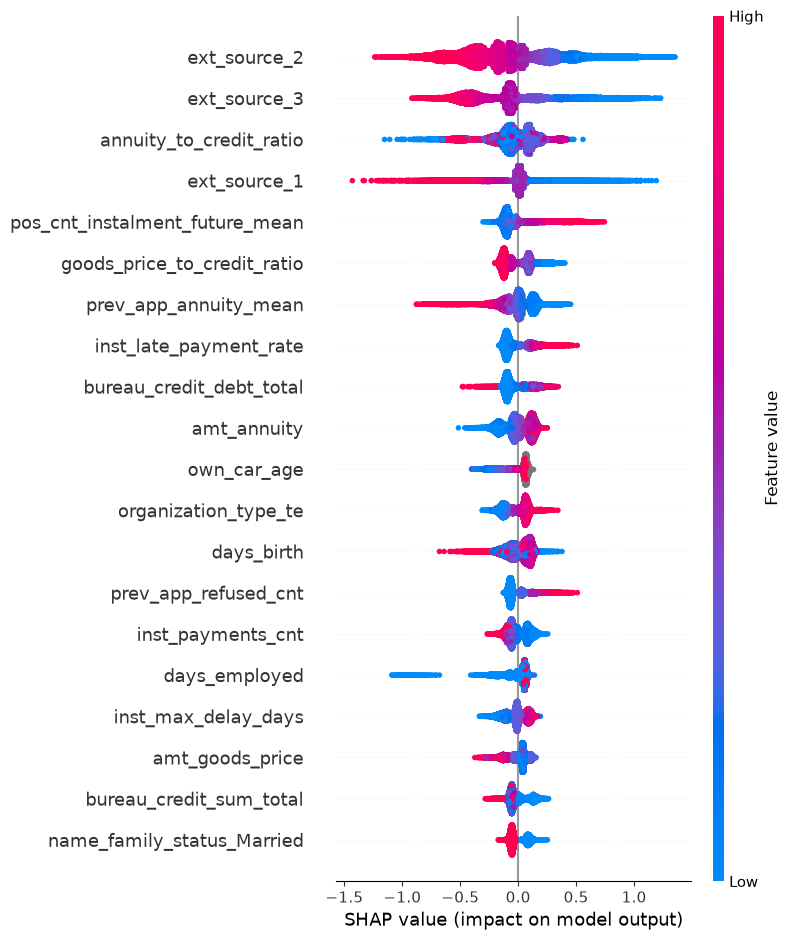

In [8]:
import shap
shap.summary_plot(shap_values, X_test, max_display=20)

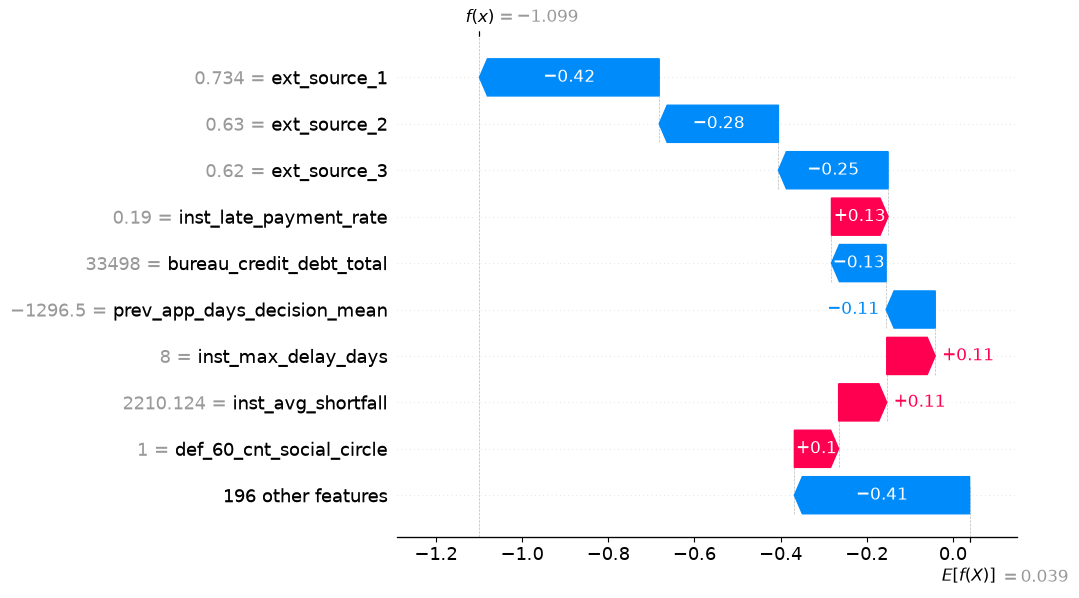

In [9]:
shap.waterfall_plot(shap.Explanation(
    values=shap_values[0],
    base_values=base_value,
    data=X_test.iloc[0],
    feature_names=X_test.columns.tolist()
))

In [10]:
def compute_shap_values(booster, X):
    dmatrix = xgb.DMatrix(X)
    output = booster.predict(dmatrix, pred_contribs=True)
    return output[:, :-1], output[0, -1]

In [11]:
import joblib
import json

# 1. Загружаем калибратор (модель уже есть в памяти как model/booster)
calibrator = joblib.load("C:/CreditScoringMLE/ml_service/app/models/calibrator.joblib")

# 2. Считаем калиброванные вероятности на X_test — именно они нужны для бизнес-порога,
# не сырые predict_proba (помним, зачем вообще калибровали в 04)
raw_proba_test = model.predict_proba(X_test)[:, 1]
calibrated_proba_test = calibrator.predict(raw_proba_test)

# 3. Сохраняем всё, что понадобится в 06, одним файлом
joblib.dump({
    "X_test": X_test,
    "y_test": y_test,
    "calibrated_proba_test": calibrated_proba_test,
}, "C:/CreditScoringMLE/ml_service/app/models/test_split_calibrated.joblib")

print("Сохранено. Shape:", X_test.shape, "| proba mean:", calibrated_proba_test.mean())

Сохранено. Shape: (30752, 205) | proba mean: 0.08023666


In [12]:
shap_helper_code = '''
import xgboost as xgb

def compute_shap_values(booster, X):
    """Обходной путь для SHAP из-за бага совместимости shap<->xgboost с base_score."""
    dmatrix = xgb.DMatrix(X)
    output = booster.predict(dmatrix, pred_contribs=True)
    return output[:, :-1], output[0, -1]
'''

with open("C:/CreditScoringMLE/ml_service/app/explainability/shap_utils.py", "w", encoding="utf-8") as f:
    f.write(shap_helper_code)

print("shap_utils.py сохранён")

shap_utils.py сохранён
